In [39]:
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import sys
sys.path.insert(0, '/pbabkin/main/mipt/nas-for-moe/code/data')
sys.path.insert(0, '/pbabkin/main/mipt/nas-for-moe/code')
import nas_moe.vae
import nas_moe.dataset
import nas_moe.surrogate
import nas_moe.single_arch
import nas_moe.graph
import nas_moe.utils
import os
from torch.utils.data import DataLoader
from torch_geometric.data import Batch
from pathlib import Path
import torch.nn as nn
from torch.utils.data import DataLoader
from torch_geometric.data import Batch
from tqdm import tqdm
from nni.nas.hub.pytorch import DARTS as DartsSpace
from torch_geometric.utils import dense_to_sparse
import random

SEED = 322
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Линейные данные

In [40]:
n_samples = 1000

X_linear = np.random.normal(loc=[0, 0], scale=[2.0, 2.0], size=(n_samples, 2))

y_linear = np.where(X_linear[:, 0] > X_linear[:, 1], 0, 1)

X_linear[:, 0] = X_linear[:, 0] - 5

# Кольцеобразные данные

In [41]:
n_per_class = n_samples // 2

# Внутреннее кольцо (класс 0)
theta_0 = np.random.uniform(0, 2 * np.pi, n_per_class)
r_0 = 1.0  # радиус внутреннего кольца
x_0 = r_0 * np.cos(theta_0) + 1
y_0 = r_0 * np.sin(theta_0)

# Внешнее кольцо (класс 1)
theta_1 = np.random.uniform(0, 2 * np.pi, n_samples - n_per_class)
r_1 = 2.0  # радиус внешнего кольца
x_1 = r_1 * np.cos(theta_1) + 1
y_1 = r_1 * np.sin(theta_1)

X_circle = np.vstack([
    np.column_stack([x_0, y_0]),
    np.column_stack([x_1, y_1])
])
y_circle = np.hstack([np.zeros(n_per_class), np.ones(n_samples - n_per_class)])

X_circle += np.random.normal(loc=0, scale=0.3, size=X_circle.shape)

indices = np.random.permutation(len(X_circle))
X_circle = X_circle[indices]
y_circle = y_circle[indices]


# Объединение

In [42]:
# Добавляем метку типа данных: 0 для линейного разделения, 1 для колец
data_type_linear = np.zeros(len(X_linear))  # 0 = линейное разделение
data_type_circle = np.ones(len(X_circle))   # 1 = кольца

# Объединяем все данные
X_combined = np.vstack([X_linear, X_circle])
y_combined = np.hstack([y_linear, y_circle])
# X_combined = np.vstack([X_xor, X_circle])
# y_combined = np.hstack([y_xor, y_circle])
data_type_combined = np.hstack([data_type_linear, data_type_circle])

# Перемешиваем объединённый датасет
indices_combined = np.random.permutation(len(X_combined))
X_combined = X_combined[indices_combined]
y_combined = y_combined[indices_combined]
data_type_combined = data_type_combined[indices_combined]

# Рисунок

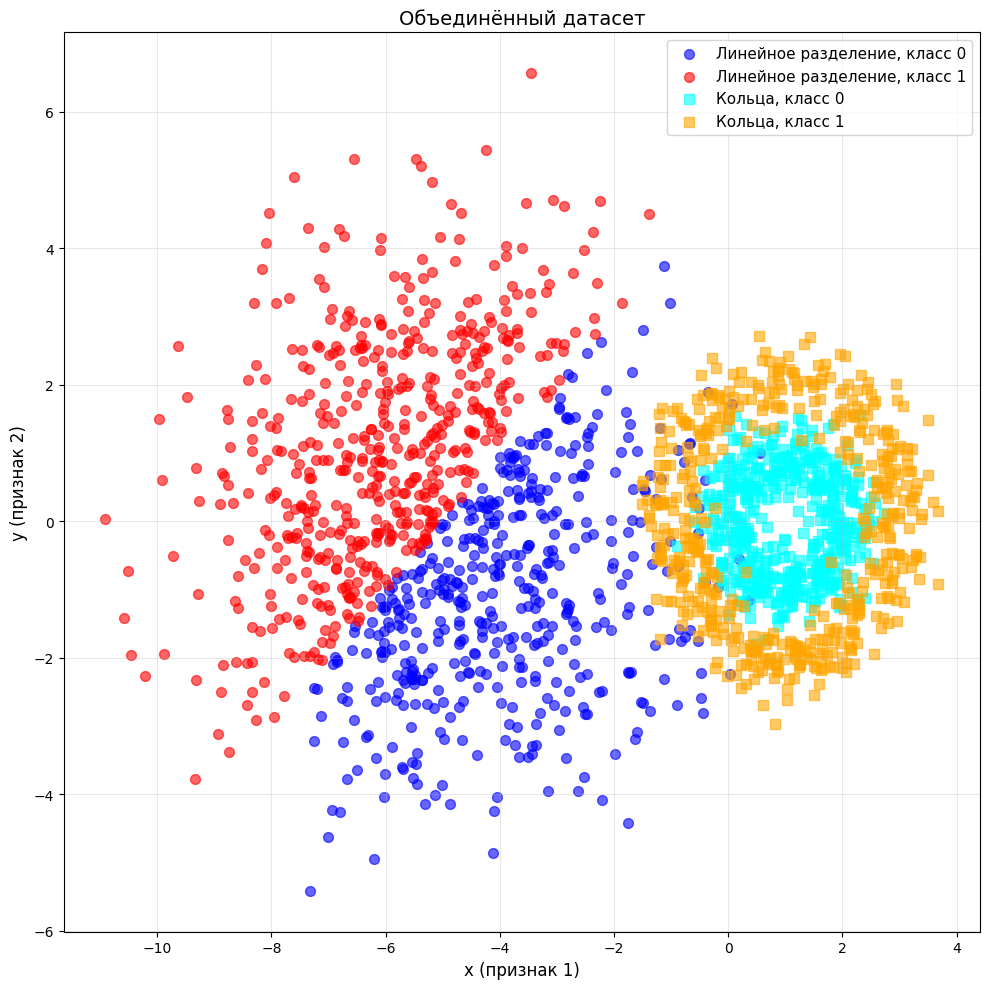

In [43]:
# Визуализация объединённого датасета
fig, ax = plt.subplots(figsize=(10, 10))

linear_mask = data_type_combined == 0
circle_mask = data_type_combined == 1

ax.scatter(X_combined[linear_mask & (y_combined == 0), 0], 
           X_combined[linear_mask & (y_combined == 0), 1], 
           label='Линейное разделение, класс 0', alpha=0.6, s=50, color='blue', marker='o')
ax.scatter(X_combined[linear_mask & (y_combined == 1), 0], 
           X_combined[linear_mask & (y_combined == 1), 1], 
           label='Линейное разделение, класс 1', alpha=0.6, s=50, color='red', marker='o')
ax.scatter(X_combined[circle_mask & (y_combined == 0), 0], 
           X_combined[circle_mask & (y_combined == 0), 1], 
           label='Кольца, класс 0', alpha=0.6, s=50, color='cyan', marker='s')
ax.scatter(X_combined[circle_mask & (y_combined == 1), 0], 
           X_combined[circle_mask & (y_combined == 1), 1], 
           label='Кольца, класс 1', alpha=0.6, s=50, color='orange', marker='s')

ax.set_xlabel('x (признак 1)', fontsize=12)
ax.set_ylabel('y (признак 2)', fontsize=12)
ax.set_title('Объединённый датасет', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
os.makedirs('/pbabkin/main/mipt/nas-for-moe/code/toy_experiment/data', exist_ok=True)
np.save('/pbabkin/main/mipt/nas-for-moe/code/toy_experiment/data/data_X.npy', X_combined)
np.save('/pbabkin/main/mipt/nas-for-moe/code/toy_experiment/data/data_y.npy', y_combined)

# Кластеризация

In [77]:
from sklearn.cluster import KMeans

n_clusters = 2

kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_combined)

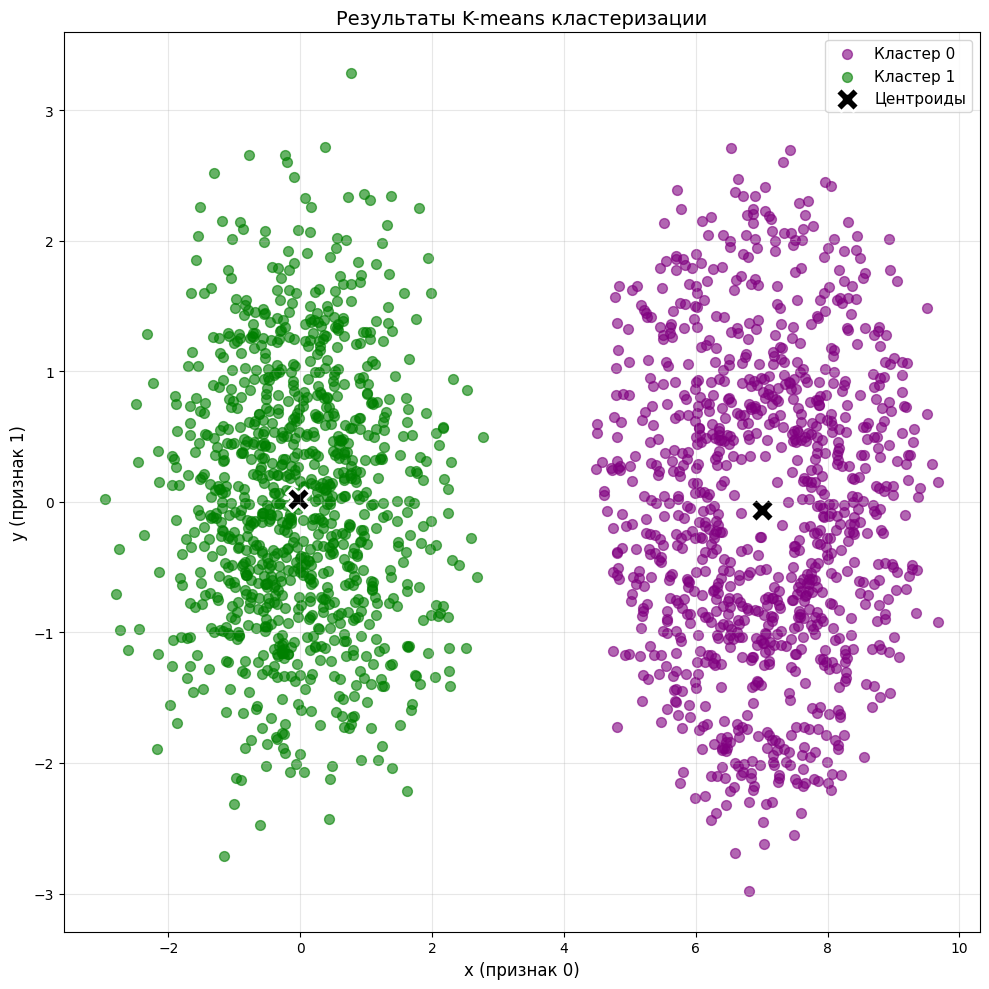

In [78]:
fig, ax = plt.subplots(figsize=(10, 10))

colors_kmeans = ['purple', 'green']
for i in range(n_clusters):
    ax.scatter(X_combined[clusters == i, 0], 
               X_combined[clusters == i, 1], 
               label=f'Кластер {i}', alpha=0.6, s=50, color=colors_kmeans[i])

# Отображаем центроиды
ax.scatter(kmeans.cluster_centers_[:, 0], 
           kmeans.cluster_centers_[:, 1], 
           label='Центроиды', marker='X', s=300, color='black', edgecolors='white', linewidth=2)

ax.set_xlabel('x (признак 0)', fontsize=12)
ax.set_ylabel('y (признак 1)', fontsize=12)
ax.set_title('Результаты K-means кластеризации', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Обучение линейной регрессии

In [79]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

cluster_0_mask = clusters == 1
X_cluster_0 = X_combined[cluster_0_mask]
y_cluster_0 = y_combined[cluster_0_mask]

print(f"Данные первого кластера:")
print(f"  Размер: {X_cluster_0.shape}")
print(f"  Количество образцов: {len(X_cluster_0)}")

# Разделяем на train и test наборы (80/20)
train_size = int(0.8 * len(X_cluster_0))
train_indices = np.random.choice(len(X_cluster_0), train_size, replace=False)
test_indices = np.array([i for i in range(len(X_cluster_0)) if i not in train_indices])

X_train = X_cluster_0[train_indices]
y_train = y_cluster_0[train_indices]
X_test = X_cluster_0[test_indices]
y_test = y_cluster_0[test_indices]

linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

y_pred_train = linear_reg.predict(X_train)
y_pred_test = linear_reg.predict(X_test)

acc = accuracy_score(y_test, np.round(y_pred_test))

print(f"  Acc (test): {acc:.4f}")

Данные первого кластера:
  Размер: (1000, 2)
  Количество образцов: 1000
  Acc (test): 0.9700


# Обучние rbf SVM на втором кластере

In [83]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

cluster_mask = clusters == 0
X_cluster = X_combined[cluster_mask]
y_cluster = y_combined[cluster_mask]

# Обучение RBF SVM на кольцеобразных данных (второй кластер)
svm_rbf = SVC(kernel='rbf', gamma='scale', C=1.0, random_state=SEED)
svm_rbf.fit(X_cluster, y_cluster)

# Предсказание
y_pred_rings_svm = svm_rbf.predict(X_cluster)

# Оценка модели
accuracy_svm = accuracy_score(y_cluster, y_pred_rings_svm)
conf_matrix_svm = confusion_matrix(y_cluster, y_pred_rings_svm)

print(f"Accuracy: {accuracy_svm:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_svm)

Accuracy: 0.9390

Confusion Matrix:
[[483  17]
 [ 44 456]]


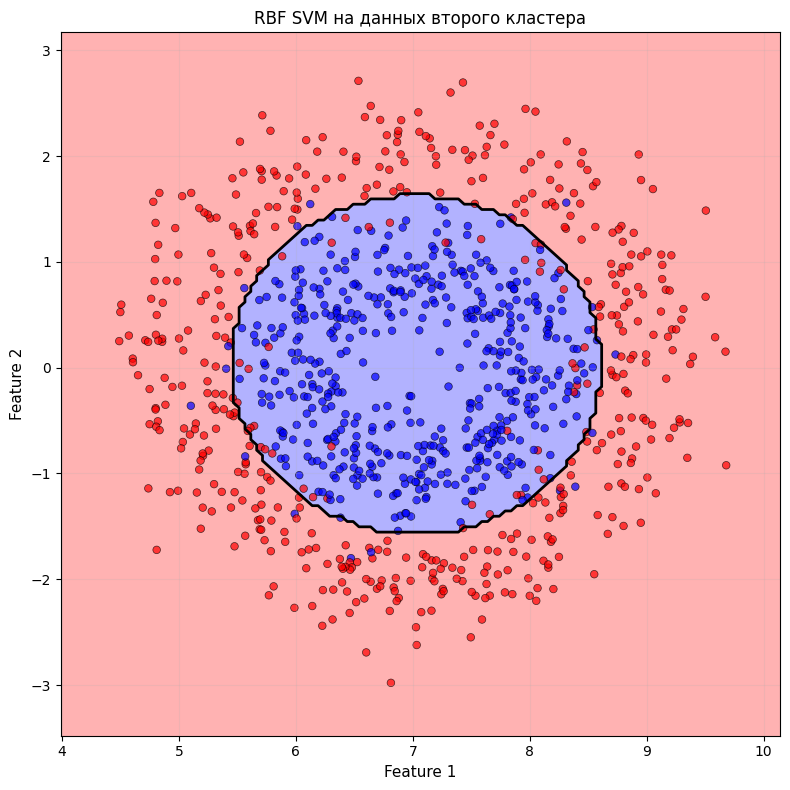

Accuracy: 0.9390


In [82]:
# Визуализация границ решения RBF SVM
h = 0.05
x_min, x_max = X_cluster[:, 0].min() - 0.5, X_cluster[:, 0].max() + 0.5
y_min, y_max = X_cluster[:, 1].min() - 0.5, X_cluster[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

Z = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 8))

# Границы решения
ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=['blue', 'red'], alpha=0.3)
ax.contour(xx, yy, Z, levels=[0.5], linewidths=2, colors='black')

# Точки данных
colors = ['blue' if c == 0 else 'red' for c in y_cluster]
ax.scatter(X_cluster[:, 0], X_cluster[:, 1], c=colors, s=30, alpha=0.7, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Feature 1', fontsize=11)
ax.set_ylabel('Feature 2', fontsize=11)
ax.set_title('RBF SVM на данных второго кластера', fontsize=12)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Accuracy: {accuracy_svm:.4f}")

# Обучение VAE на объединённых данных

In [85]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Определение VAE модели
class VAE(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, latent_dim=2):
        super(VAE, self).__init__()
        
        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)
        
    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z
    
    def decode(self, z):
        h = torch.relu(self.fc3(z))
        x_recon = self.fc4(h)
        return x_recon
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# Loss function (ELBO)
def vae_loss(x_recon, x, mu, logvar):
    # Reconstruction loss
    recon_loss = nn.MSELoss(reduction='mean')(x_recon, x)
    # KL divergence
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

# Подготовка данных
X_combined_tensor = torch.FloatTensor(X_combined)
dataset = TensorDataset(X_combined_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Инициализация модели
vae = VAE(input_dim=2, hidden_dim=64, latent_dim=2)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# Обучение
num_epochs = 100
losses = []

print("Обучение VAE...")
for epoch in range(num_epochs):
    epoch_loss = 0
    for batch in dataloader:
        x = batch[0]
        optimizer.zero_grad()
        x_recon, mu, logvar = vae(x)
        loss = vae_loss(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}")

print("Обучение завершено!")


Обучение VAE...
Epoch 20/100, Loss: 1.5120
Epoch 40/100, Loss: 1.4725
Epoch 60/100, Loss: 1.4552
Epoch 80/100, Loss: 1.4424
Epoch 100/100, Loss: 1.4000
Обучение завершено!


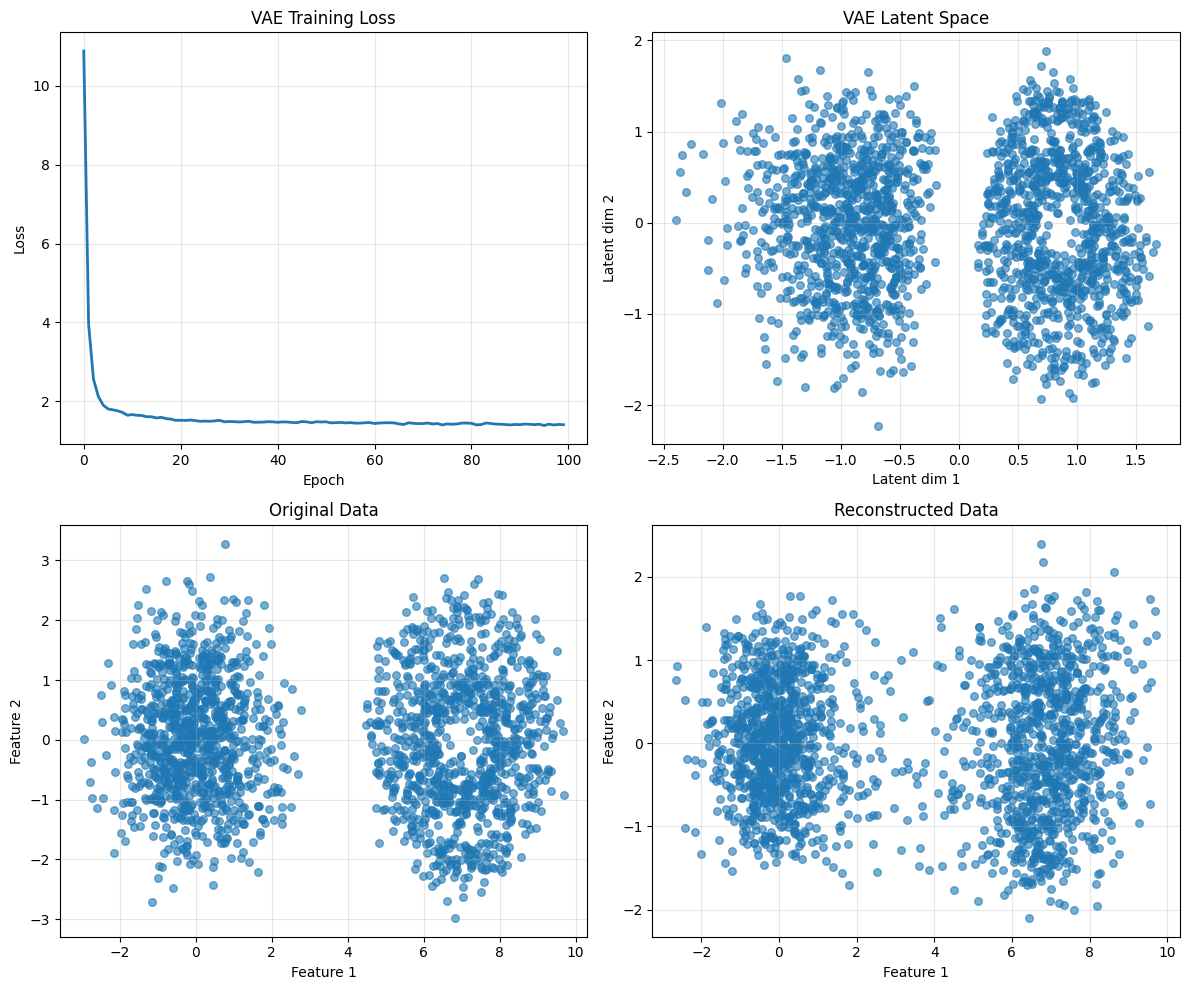

In [91]:
# Визуализация результатов
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. График потерь
axes[0, 0].plot(losses, linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('VAE Training Loss')
axes[0, 0].grid(True, alpha=0.3)

# 2. Скрытое пространство
with torch.no_grad():
    mu, _ = vae.encode(X_combined_tensor)
    z = mu.numpy()

axes[0, 1].scatter(z[:, 0], z[:, 1], alpha=0.6, s=30)
axes[0, 1].set_xlabel('Latent dim 1')
axes[0, 1].set_ylabel('Latent dim 2')
axes[0, 1].set_title('VAE Latent Space')
axes[0, 1].grid(True, alpha=0.3)

# 3. Исходные данные
axes[1, 0].scatter(X_combined[:, 0], X_combined[:, 1], alpha=0.6, s=30)
axes[1, 0].set_xlabel('Feature 1')
axes[1, 0].set_ylabel('Feature 2')
axes[1, 0].set_title('Original Data')
axes[1, 0].grid(True, alpha=0.3)

# 4. Реконструированные данные
with torch.no_grad():
    X_recon, _, _ = vae(X_combined_tensor)
    X_recon = X_recon.numpy()

axes[1, 1].scatter(X_recon[:, 0], X_recon[:, 1], alpha=0.6, s=30)
axes[1, 1].set_xlabel('Feature 1')
axes[1, 1].set_ylabel('Feature 2')
axes[1, 1].set_title('Reconstructed Data')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Кластеризация латентных представлений VAE

In [92]:
# Кластеризация латентных представлений
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Получаем латентные представления
with torch.no_grad():
    z_latent, _ = vae.encode(X_combined_tensor)
    z_latent = z_latent.numpy()

# K-means кластеризация
n_clusters_latent = 2
kmeans_latent = KMeans(n_clusters=n_clusters_latent, random_state=SEED, n_init=10)
clusters_latent = kmeans_latent.fit_predict(z_latent)

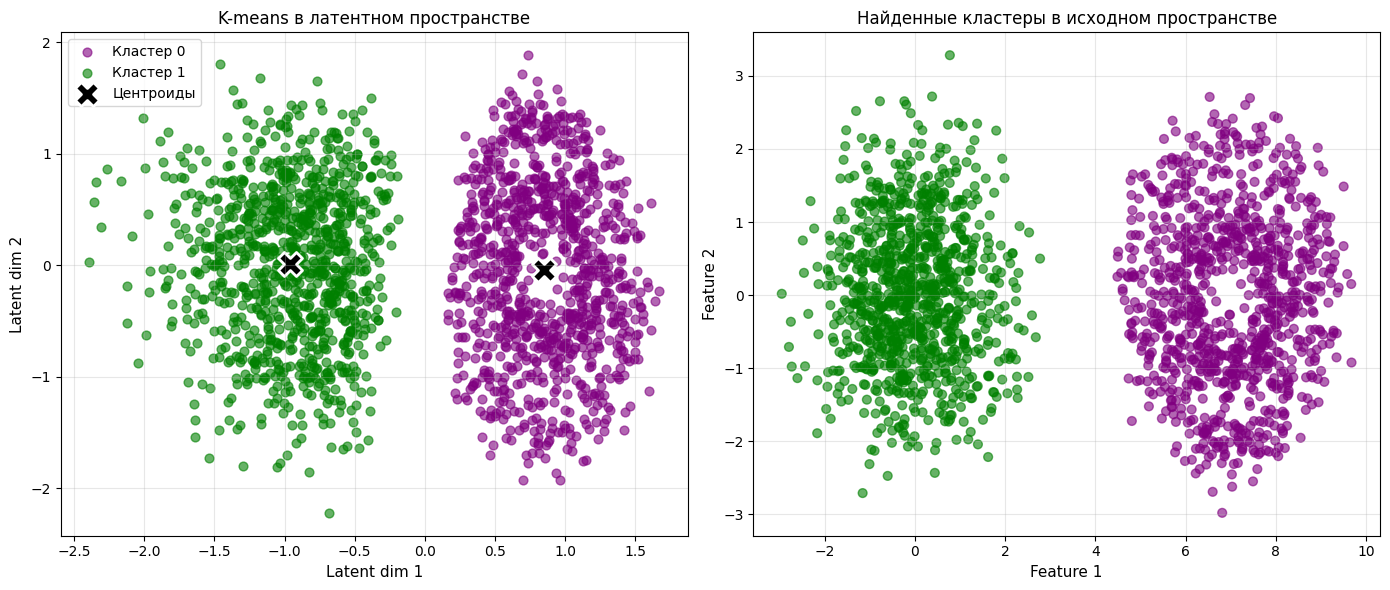

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_map = ['purple', 'green']

for i in range(n_clusters_latent):
    mask = clusters_latent == i
    axes[0].scatter(z_latent[mask, 0], z_latent[mask, 1], 
                   label=f'Кластер {i}', alpha=0.6, s=40, color=colors_map[i])

# Центроиды
axes[0].scatter(kmeans_latent.cluster_centers_[:, 0], 
               kmeans_latent.cluster_centers_[:, 1],
               marker='X', s=300, color='black', edgecolors='white', linewidth=2,
               label='Центроиды')
axes[0].set_xlabel('Latent dim 1', fontsize=11)
axes[0].set_ylabel('Latent dim 2', fontsize=11)
axes[0].set_title('K-means в латентном пространстве', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

found_cluster_colors = ['purple' if c == 0 else 'green' for c in clusters_latent]
axes[1].scatter(X_combined[:, 0], X_combined[:, 1], c=found_cluster_colors,
               alpha=0.6, s=40)
axes[1].set_xlabel('Feature 1', fontsize=11)
axes[1].set_ylabel('Feature 2', fontsize=11)
axes[1].set_title('Найденные кластеры в исходном пространстве', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
